In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import visualkeras
from PIL import ImageFont
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

from tensorflow.keras.preprocessing import image_dataset_from_directory
import random
random.seed(42)

ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)
random_seed = 55
num_classes = 5
epochs = 128

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=random_seed
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

In [ ]:
def text_callable(layer_index, layer):
    # Every other piece of text is drawn above the layer, the first one below
    above = bool(layer_index%2)

    # Get the output shape of the layer
    output_shape = [x for x in list(layer.output_shape) if x is not None]

    # If the output shape is a list of tuples, we only take the first one
    if isinstance(output_shape[0], tuple):
        output_shape = list(output_shape[0])
        output_shape = [x for x in output_shape if x is not None]

    # Variable to store text which will be drawn    
    output_shape_txt = ""

    # Create a string representation of the output shape
    for ii in range(len(output_shape)):
        output_shape_txt += str(output_shape[ii])
        if ii < len(output_shape) - 2: # Add an x between dimensions, e.g. 3x3
            output_shape_txt += "x"
        if ii == len(output_shape) - 2: # Add a newline between the last two dimensions, e.g. 3x3 \n 64
            output_shape_txt += "\n"

    # Add the name of the layer to the text, as a new line
    output_shape_txt += f"\n{layer.name}"

    # Return the text value and if it should be drawn above the layer
    return output_shape_txt, above

In [ ]:
# SE katmanı olmayan model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Modeli oluşturma
model = Sequential()

# 1. Evrişim Katmanı
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D((2, 2)))

# 2. Evrişim Katmanı
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 3. Evrişim Katmanı
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 4. Evrişim Katmanı
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# 5. Evrişim Katmanı
model.add(Conv2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Düzleştirme katmanı
model.add(Flatten())

# Tam bağlantılı katmanlar
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Çıkış katmanı (örneğin, 10 sınıflı bir sınıflandırma için)
model.add(Dense(num_classes, activation='softmax'))

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)  # using comic sans is strictly prohibited!

visualkeras.layered_view(model, 
                            draw_volume=True,
                            legend=False, 
                            font=font, 
                            show_dimension=True,
                            scale_xy=2, 
                            scale_z=.1,
                            max_z=60,
                            spacing=60,
                            text_callable=text_callable,
                         )

In [37]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_25 (Conv2D)          (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_25 (MaxPoolin  (None, 111, 111, 32)     0         
 g2D)                                                            
                                                                 
 conv2d_26 (Conv2D)          (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_26 (MaxPoolin  (None, 54, 54, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_27 (Conv2D)          (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_27 (MaxPoolin  (None, 26, 26, 128)     

In [ ]:
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)  # using comic sans is strictly prohibited!
visualkeras.layered_view(model, 
                            draw_volume=False,
                            legend=False, 
                            font=font, 
                            show_dimension=False,
                             scale_xy=2, 
                            scale_z=.1,
                            max_z=60,
                            spacing=60,
                           #  text_callable=text_callable  # Özelleştirilmiş metin fonksiyonunu ekler
                         )

In [29]:
# Modeli eğitmek için kod
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor for improvement
    patience=3,  # Number of epochs to wait before stopping
    restore_best_weights=True  # Restore the best model weights
)

# Train the model
callbacks=[early_stopping]

history= model.fit(
    train_gen,
    epochs=epochs,
    batch_size=batch_size, # Number
    validation_data=valid_gen,
    callbacks=callbacks
)

203/203 [==============================] - 19s 86ms/step - loss: 1.3684 - accuracy: 0.3702 - val_loss: 1.1166 - val_accuracy: 0.5012
Epoch 2/128
203/203 [==============================] - 19s 93ms/step - loss: 1.1533 - accuracy: 0.5125 - val_loss: 1.0858 - val_accuracy: 0.5000
Epoch 3/128
203/203 [==============================] - 17s 83ms/step - loss: 1.0855 - accuracy: 0.5693 - val_loss: 1.0916 - val_accuracy: 0.5457
Epoch 4/128
203/203 [==============================] - 18s 90ms/step - loss: 1.0343 - accuracy: 0.6088 - val_loss: 0.9624 - val_accuracy: 0.6222
Epoch 5/128
203/203 [==============================] - 18s 87ms/step - loss: 0.9860 - accuracy: 0.6348 - val_loss: 0.9966 - val_accuracy: 0.6062
Epoch 6/128
203/203 [==============================] - 17s 86ms/step - loss: 0.9164 - accuracy: 0.6789 - val_loss: 0.8172 - val_accuracy: 0.6840
Epoch 7/128
203/203 [==============================] - 18s 86ms/step - loss: 0.8577 - accuracy: 0.6996 - val_loss: 0.7513 - val_accuracy: 0.70

In [30]:
# import tensorflow as tf
# import pickle

# # Keras modelini yükleme
# model = tf.keras.models.load_model("model1.h5")

# # Eğitim geçmişini yükleme
# with open('model1.pkl', 'rb') as file:
#     history = pickle.load(file)

# # history değişkeni içindeki veriyi kontrol etme
# print(history.keys())


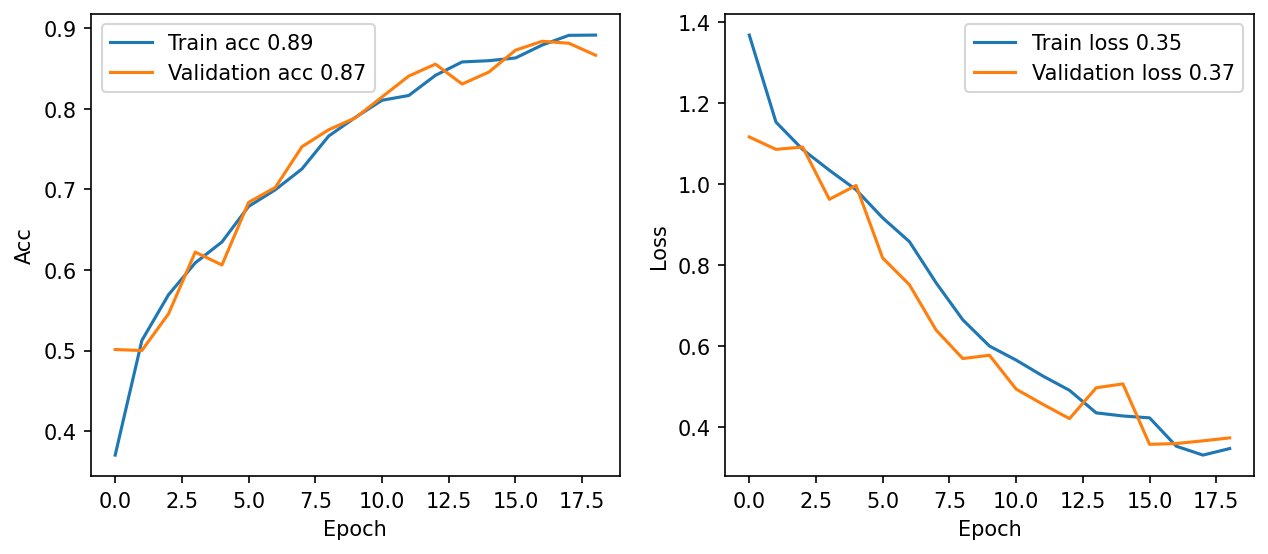

In [31]:
from helper import Helper
_helper = Helper()
_helper.plot_train_and_val_curves(history)

51/51 [==============================] - 4s 71ms/step


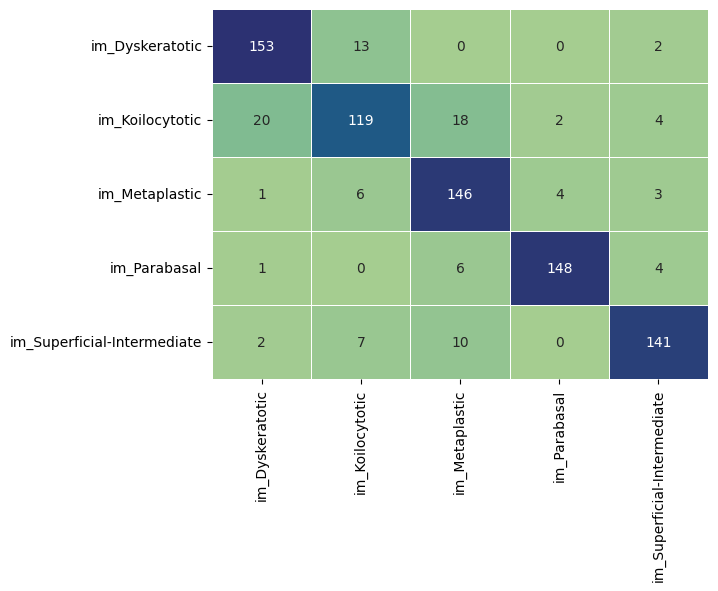

In [32]:
_helper.plot_confusion_matrix(model, valid_gen)

51/51 [==============================] - 3s 62ms/step


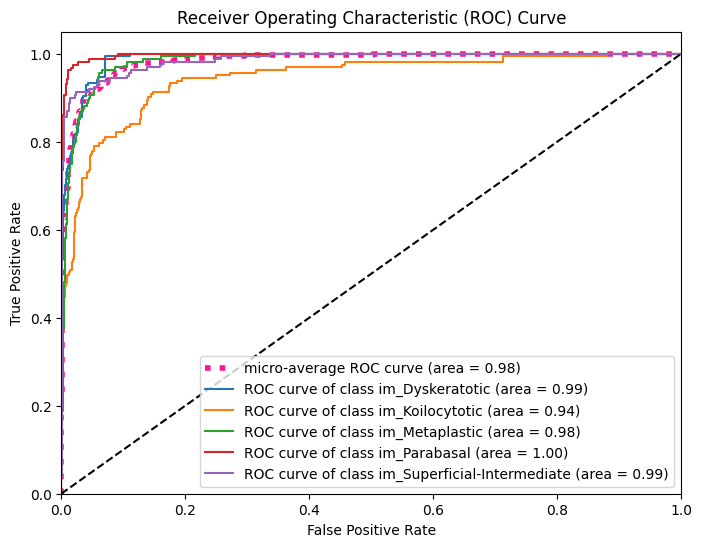

In [33]:
_helper.plot_roc_curve(model, valid_gen)

In [34]:
import pickle
model.save("model1.h5")
# history değişkenini pickle ile kaydetme
with open('model1.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [35]:
from confusion import Confusion
cm = _helper.get_confusion_matrix(model, valid_gen)


51/51 [==============================] - 3s 63ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       168
           1       0.82      0.73      0.77       163
           2       0.81      0.91      0.86       160
           3       0.96      0.93      0.95       159
           4       0.92      0.88      0.90       160

    accuracy                           0.87       810
   macro avg       0.87      0.87      0.87       810
weighted avg       0.87      0.87      0.87       810

Confusion Matrix:
[[153  13   0   0   2]
 [ 20 119  18   2   4]
 [  1   6 146   4   3]
 [  1   0   6 148   4]
 [  2   7  10   0 141]]


In [36]:
performances = Confusion.getValues(cm)
performances

,Value
Accuracy,0.8728
Error,0.1272
Sensitivity,0.8731
Specificity,0.9682
Precision,0.8746
FalsePositiveRate,0.0318
F1_score,0.8725
MatthewsCorrelationCoefficient,0.8418
